In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:

# Definir la ruta de la carpeta data
data_path = os.path.join("data")

# Obtener todos los archivos Excel
excel_files = [f for f in os.listdir(data_path) if f.endswith('.xlsx')]

# Crear un diccionario para almacenar los dataframes
dataframes = {}

# Ciclo for para cargar cada archivo Excel
for file in excel_files:
    file_path = os.path.join(data_path, file)
    # Usar el nombre del archivo sin extensión como clave
    df_name = file.replace('.xlsx', '')
    dataframes[df_name] = pd.read_excel(file_path)
    print(f"Cargado: {file}")

# Mostrar los dataframes cargados
print(f"\nTotal de archivos cargados: {len(dataframes)}")
print(f"Dataframes disponibles: {list(dataframes.keys())}")


Cargado: LaLiga19 20.xlsx
Cargado: LaLiga21 22.xlsx
Cargado: LaLiga17 18.xlsx
Cargado: LaLiga20 21.xlsx
Cargado: LaLiga16 17.xlsx
Cargado: LaLiga18 19.xlsx

Total de archivos cargados: 6
Dataframes disponibles: ['LaLiga19 20', 'LaLiga21 22', 'LaLiga17 18', 'LaLiga20 21', 'LaLiga16 17', 'LaLiga18 19']


In [4]:
dataframes.keys()

dict_keys(['LaLiga19 20', 'LaLiga21 22', 'LaLiga17 18', 'LaLiga20 21', 'LaLiga16 17', 'LaLiga18 19'])

In [5]:
display(dataframes['LaLiga19 20'].head())

,Wk,Day,Date,Time,Local,xG,Score,xG.1,Visitante,Attendance,Venue,Referee,Informe del partido,Notes
0,1.0,Vie,2019-08-16,21:00 (15:00),Athletic Club,0.5,1–0,0.9,Barcelona,47.693,San Mamés,Carlos del Cerro,Informe del partido,NaN
1,1.0,Sáb,2019-08-17,17:00 (11:00),Celta Vigo,0.8,1–3,1.5,Real Madrid,23.566,Estadio de Balaídos,Javier Estrada,Informe del partido,NaN
2,1.0,Sáb,2019-08-17,19:00 (13:00),Valencia,2.3,1–1,1.3,Real Sociedad,41.846,Estadio de Mestalla,Jesús Gil,Informe del partido,NaN
3,1.0,Sáb,2019-08-17,20:00 (14:00),Mallorca,1.7,2–1,0.7,Eibar,15.127,Iberostar Estadi,Mario Melero,Informe del partido,NaN
4,1.0,Sáb,2019-08-17,21:00 (15:00),Villarreal,1.6,4–4,2.2,Granada,14.753,Estadio de la Cerámica,Adrián Cordero,Informe del partido,NaN


In [6]:
equipos = ['Real Madrid', 'Barcelona']
columnas_a_borrar = ['Day', 'Time', 'xG', 'xG.1', 'Referee', 'Informe del partido', 'Notes']

dataframes_filtrados = {}

for key, df in dataframes.items():
    filtro = df['Local'].isin(equipos) | df['Visitante'].isin(equipos) #que el local o el visitante esté en los equipos
    df_filtrado = df[filtro]
    df_limpio = df_filtrado.drop(columns=columnas_a_borrar, errors='ignore') #eliminar las columnas que no son de interes
    dataframes_filtrados[key] = df_limpio #guardo el cambio

# Para verificar el resultado del primer dataframe:
display(dataframes_filtrados['LaLiga19 20'].head())

,Wk,Date,Local,Score,Visitante,Attendance,Venue
0,1.0,2019-08-16,Athletic Club,1–0,Barcelona,47.693,San Mamés
1,1.0,2019-08-17,Celta Vigo,1–3,Real Madrid,23.566,Estadio de Balaídos
14,2.0,2019-08-24,Real Madrid,1–1,Valladolid,63.037,Estadio Santiago Bernabéu
20,2.0,2019-08-25,Barcelona,5–2,Betis,79.159,Camp Nou
24,3.0,2019-08-31,Osasuna,2–2,Barcelona,16.742,Estadio El Sadar


In [7]:
lista_goles_por_año = []

equipos = ['Real Madrid', 'Barcelona']

for temporada, df in dataframes_filtrados.items():
    # 1. Hacemos una copia para no alterar el dataframe original y evitar advertencias
    df_temp = df.copy()
    
    # 2. Separar la columna 'Score' en Goles_Local y Goles_Visitante. 
    # Usamos la expresión regular r'[-–]' por si el guion es normal (-) o largo (–)
    df_temp[['Goles_Local', 'Goles_Visitante']] = df_temp['Score'].astype(str).str.split(r'[-–]', expand=True).astype(float)
    
    # Lista temporal para guardar los datos de los equipos en esta temporada en particular
    datos_equipos = []
    
    # 3. Calculamos los goles por equipo
    for equipo in equipos:
        # Goles anotados en casa: filtramos donde el equipo es Local y sumamos los Goles_Local
        goles_local = df_temp[df_temp['Local'] == equipo]['Goles_Local'].sum()
        
        # Goles anotados fuera: filtramos donde el equipo es Visitante y sumamos los Goles_Visitante
        goles_visita = df_temp[df_temp['Visitante'] == equipo]['Goles_Visitante'].sum()
        
        # Guardamos la información
        datos_equipos.append({
            'Temporada': temporada,
            'Equipo': equipo,
            'Goles Local': int(goles_local),
            'Goles Visita': int(goles_visita),
            'Goles Totales': int(goles_local + goles_visita)
        })
    
    # 4. Convertimos el resumen de este año en un DataFrame y lo añadimos a nuestra lista
    df_resumen_año = pd.DataFrame(datos_equipos)
    lista_goles_por_año.append(df_resumen_año)

# --- Para visualizar los resultados ---
# Si quieres ver el resumen del primer año en la lista:
print("Resumen de la primera temporada procesada:")
for df in lista_goles_por_año:
    print('='*30)
    display(df)

Resumen de la primera temporada procesada:


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga19 20,Real Madrid,40,30,70
1,LaLiga19 20,Barcelona,52,34,86


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga21 22,Real Madrid,44,36,80
1,LaLiga21 22,Barcelona,37,31,68


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga17 18,Real Madrid,54,40,94
1,LaLiga17 18,Barcelona,53,46,99


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga20 21,Real Madrid,33,34,67
1,LaLiga20 21,Barcelona,44,41,85


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga16 17,Real Madrid,48,58,106
1,LaLiga16 17,Barcelona,64,52,116


,Temporada,Equipo,Goles Local,Goles Visita,Goles Totales
0,LaLiga18 19,Real Madrid,32,31,63
1,LaLiga18 19,Barcelona,51,39,90


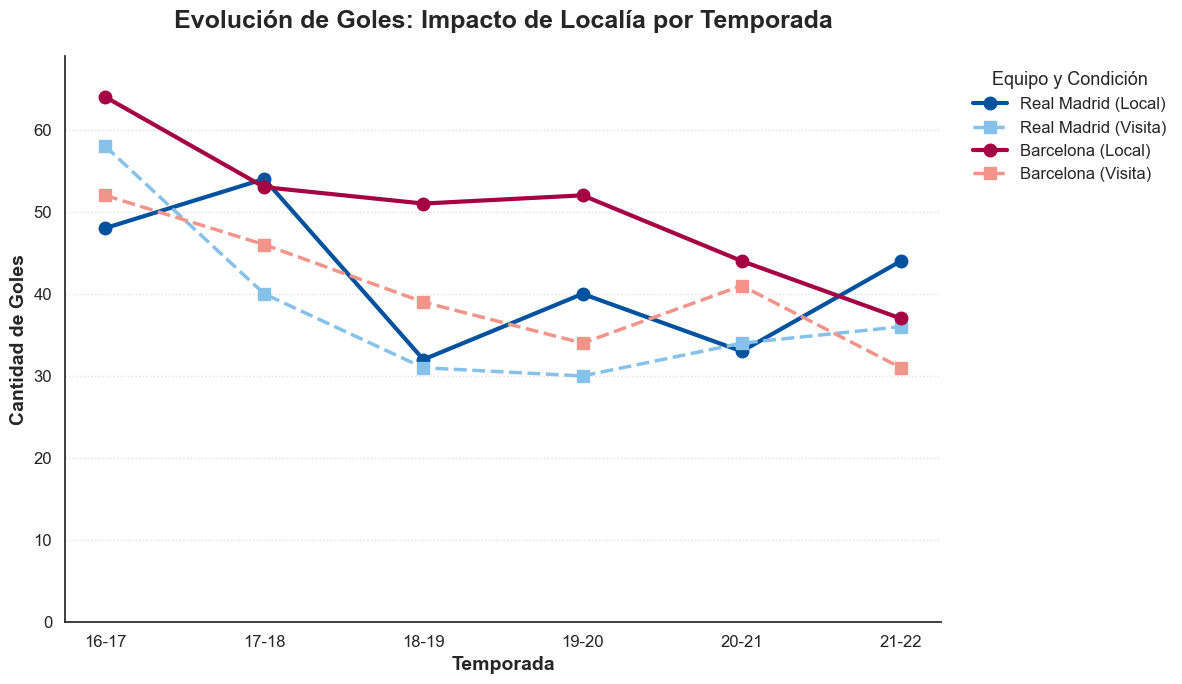

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Unimos la data y ordenamos el tiempo
df_completo = pd.concat(lista_goles_por_año, ignore_index=True)
# Formato limpio para el eje X (ej: "16-17")
df_completo['Temporada_Corta'] = df_completo['Temporada'].str.replace('LaLiga', '').str.replace(' ', '-')
df_completo = df_completo.sort_values('Temporada_Corta')

# Separamos los equipos
df_rm = df_completo[df_completo['Equipo'] == 'Real Madrid']
df_fcb = df_completo[df_completo['Equipo'] == 'Barcelona']

# 2. Configuración "Menos es Más" (eliminamos el fondo gris)
sns.set_theme(style="white")
plt.figure(figsize=(12, 7))

# 3. Trazado de líneas (Colores representativos e intuitivos)
# REAL MADRID: Tonos azules/grisáceos
# Local: Línea gruesa y oscura, marcador redondo
plt.plot(df_rm['Temporada_Corta'], df_rm['Goles Local'], marker='o', markersize=9, 
         color='#00529F', linewidth=3, label='Real Madrid (Local)')
# Visita: Línea punteada y clara, marcador cuadrado
plt.plot(df_rm['Temporada_Corta'], df_rm['Goles Visita'], marker='s', markersize=8, 
         color='#85C1E9', linewidth=2.5, linestyle='--', label='Real Madrid (Visita)')

# BARCELONA: Tonos rojizos/blaugranas
# Local: Línea gruesa y oscura, marcador redondo
plt.plot(df_fcb['Temporada_Corta'], df_fcb['Goles Local'], marker='o', markersize=9, 
         color='#A50044', linewidth=3, label='Barcelona (Local)')
# Visita: Línea punteada y clara, marcador cuadrado
plt.plot(df_fcb['Temporada_Corta'], df_fcb['Goles Visita'], marker='s', markersize=8, 
         color='#F1948A', linewidth=2.5, linestyle='--', label='Barcelona (Visita)')

# 4. SOLIDEZ DE DATOS: NO CORTAR EL EJE Y
# Forzamos matemáticamente a que el gráfico de goles empiece desde CERO
max_goles = df_completo[['Goles Local', 'Goles Visita']].max().max() + 5
plt.ylim(0, max_goles)

# 5. Jerarquía visual y legibilidad (Feedback del documento)
plt.title('Evolución de Goles: Impacto de Localía por Temporada', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Temporada', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Goles', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 6. Limpieza visual (Maximizando el "Data-Ink Ratio")
sns.despine() # Quita las líneas innecesarias arriba y a la derecha
plt.grid(axis='y', linestyle=':', alpha=0.6) # Líneas guía horizontales muy sutiles

# 7. Leyenda eficiente y limpia
plt.legend(title='Equipo y Condición', title_fontsize='13', fontsize='12', 
           bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Ajuste automático de márgenes para que nada quede cortado
plt.tight_layout()
plt.show()

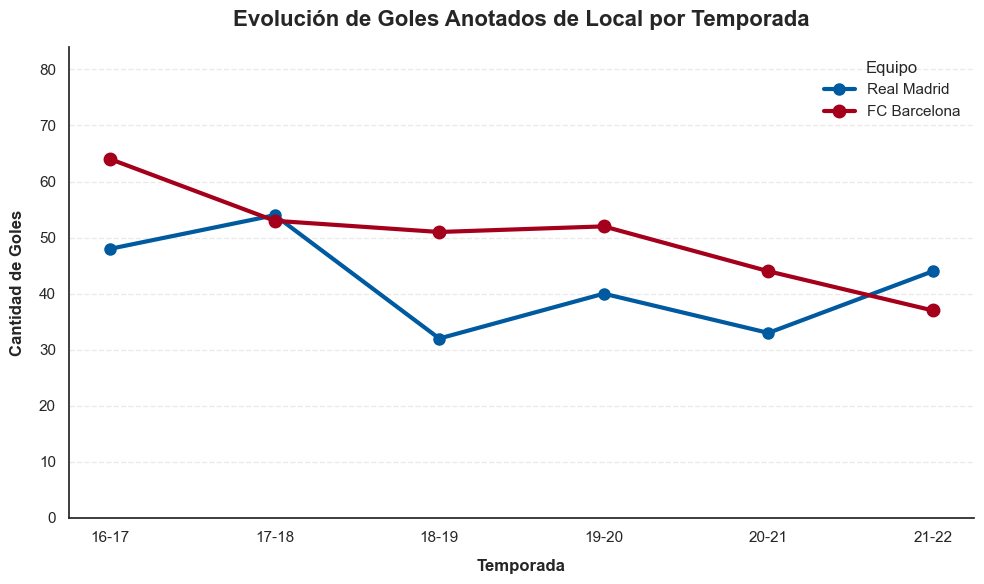

<Figure size 640x480 with 0 Axes>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PROCESAMIENTO DE DATOS
# ==========================================
datos_local = []
equipos = ['Real Madrid', 'Barcelona']

for temporada, df in dataframes_filtrados.items():
    df_temp = df.copy()
    
    # Separamos la columna Score para extraer los goles del equipo local
    df_temp[['Goles_Local', 'Goles_Visitante']] = df_temp['Score'].astype(str).str.split(r'[-–]', expand=True).astype(float)
    
    for equipo in equipos:
        # Filtramos estrictamente donde el equipo jugó en casa (Local) y sumamos
        goles_en_casa = df_temp[df_temp['Local'] == equipo]['Goles_Local'].sum()
        
        datos_local.append({
            'Temporada': temporada,
            'Equipo': equipo,
            'Goles Local': int(goles_en_casa)
        })

# Convertimos a DataFrame para facilitar el gráfico
df_goles = pd.DataFrame(datos_local)

# Limpiamos el texto de la temporada para el eje X (ej: "LaLiga16 17" -> "16-17")
df_goles['Temporada_Corta'] = df_goles['Temporada'].str.replace('LaLiga', '').str.replace(' ', '-')
df_goles = df_goles.sort_values('Temporada_Corta') # Orden cronológico fundamental

# Separamos por equipo
df_rm = df_goles[df_goles['Equipo'] == 'Real Madrid']
df_fcb = df_goles[df_goles['Equipo'] == 'Barcelona']

# ==========================================
# 2. DISEÑO DE LA VISUALIZACIÓN
# ==========================================
sns.set_theme(style="white") # Principio: Menos es más (sin fondos invasivos)
plt.figure(figsize=(10, 6))

# Trazamos las líneas con marcadores grandes ('o') para resaltar los datos exactos
# Real Madrid: Azul Rey oscuro
plt.plot(df_rm['Temporada_Corta'], df_rm['Goles Local'], marker='o', markersize=8, 
         color="#005A9F", linewidth=3, label='Real Madrid')

# Barcelona: Rojo Carmesí / Blaugrana
plt.plot(df_fcb['Temporada_Corta'], df_fcb['Goles Local'], marker='o', markersize=9, 
         color="#A5001B", linewidth=3, label='FC Barcelona')

# SOLIDEZ ESTADÍSTICA: El eje Y siempre debe iniciar en 0
max_goles = df_goles['Goles Local'].max() + 20 # Damos un margen superior para que respire
plt.ylim(0, max_goles)

# Jerarquía visual (Textos y etiquetas)
plt.title('Evolución de Goles Anotados de Local por Temporada', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Temporada', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Cantidad de Goles', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Eficiencia Visual: Retiramos los bordes superior y derecho del gráfico
sns.despine()

# Agregamos una cuadrícula horizontal muy tenue para ayudar a medir los valores
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Colocamos la leyenda limpia, sin marcos que estorben
plt.legend(title='Equipo', title_fontsize='12', fontsize='11', 
           loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

# Guarda la imagen en alta resolución y sin cortar los bordes
plt.savefig('grafico_localia.png', dpi=300, bbox_inches='tight')
